# Optimization of Squared Loss — The One Powerline Problem

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture introducing the **power-line /
squared-loss** optimization (Week 1 — Derivatives and Optimization).

This notebook explains:

- the problem: place a house to **minimize the cost** of connecting to power lines
- why it matters: the cost is the **squared error**, central to machine learning
- the cost model: connecting at distance $x$ costs $x^2$
- the simplest case (**one** power line) — minimize $x^2$, build right at the line
- the calculus ($f'(x) = 2x = 0 \Rightarrow x = 0$), with a plot

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Introduction to Optimization*.

## 1. The problem

You must build a **house** and connect it to several **power lines** for the best supply.
Connecting is **expensive**: the farther the house, the longer and thicker the cable. Where
should the house go to minimize the total cost?

> *"The function you're minimizing is very similar to the squared error — one of the most
> important functions in machine learning, used to train linear regression and certain
> neural networks."*

## 2. The cost model

Connecting to a power line a distance $x$ away costs the **square** of that distance:

$$
\text{cost} = x^2 .
$$

(Squaring reflects that distance is penalized more and more as it grows — and it matches the
**squared error**.) The goal is to minimize the **total** cost of connecting to all the
power lines.

## 3. The simplest case: one power line

With a **single** power line, the cost as a function of the house position $x$ (relative to
the line at $0$) is

$$
f(x) = x^2 .
$$

Where is this smallest? Right **at** the power line: distance $0$ gives cost $0^2 = 0$.
The calculus agrees — set the derivative to zero:

$$
f'(x) = 2x = 0 \quad\Rightarrow\quad x = 0 .
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x')
f = x**2
fp = sp.diff(f, x)
print("cost f(x) =", f)
print("f'(x) =", fp)
print("minimum where f'(x)=0:  x =", sp.solve(fp, x)[0])
print("minimum cost: f(0) =", f.subs(x, 0))

cost f(x) = x**2
f'(x) = 2*x
minimum where f'(x)=0:  x = 0
minimum cost: f(0) = 0


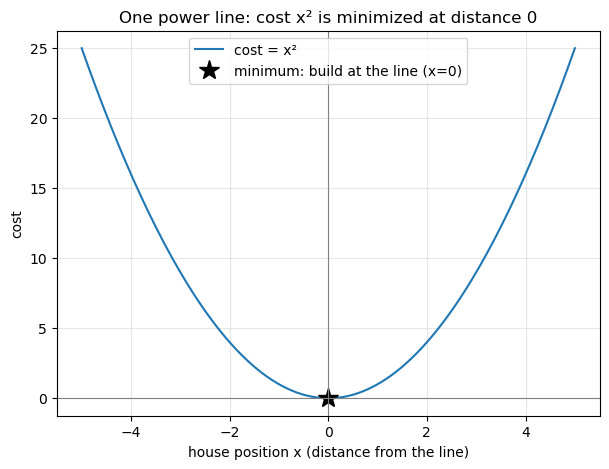

In [2]:
xs = np.linspace(-5, 5, 200)
plt.figure(figsize=(7, 5))
plt.plot(xs, xs**2, label="cost = x²")
plt.plot(0, 0, "k*", markersize=15, label="minimum: build at the line (x=0)")
plt.axhline(0, color="gray", lw=0.8); plt.axvline(0, color="gray", lw=0.8)
plt.title("One power line: cost x² is minimized at distance 0")
plt.xlabel("house position x (distance from the line)"); plt.ylabel("cost")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 4. Toward more power lines

With one line the answer is trivial (sit on it). With **several** power lines you can't be
at all of them, so you minimize the **sum of squared distances**:

$$
f(x) = (x - p_1)^2 + (x - p_2)^2 + \cdots + (x - p_n)^2 ,
$$

where $p_1, \dots, p_n$ are the power-line positions. This is exactly the **squared-loss /
least-squares** objective — the next lectures solve it, and it is the backbone of linear
regression.

A quick preview: the minimizer is the **average** of the positions.

In [3]:
# preview: sum of squared distances to several power lines
positions = [1.0, 4.0, 6.0]
xs = sp.symbols('xs')
total = sum((xs - p)**2 for p in positions)
best = sp.solve(sp.diff(total, xs), xs)[0]
print("total cost f(x) =", sp.expand(total))
print("minimizing position x =", best, " (= the average of", positions, "=", np.mean(positions), ")")

total cost f(x) = 3.0*xs**2 - 22.0*xs + 53.0
minimizing position x = 3.66666666666667  (= the average of [1.0, 4.0, 6.0] = 3.6666666666666665 )


## 5. Exercises

### Basic
1. What is the cost of connecting to a power line a distance $x$ away?
2. For one power line, where should the house go, and what is the cost there?

### Intermediate
3. Minimize $f(x) = x^2$ using its derivative.
4. Why is the cost a *square* of the distance rather than just the distance?

### Advanced
5. For power lines at $2$ and $8$, write the total cost $f(x)$ and find the minimizing $x$.
6. Show that for power lines at $p_1, \dots, p_n$, the cost
   $\sum (x - p_i)^2$ is minimized at the average $\bar p = \tfrac1n\sum p_i$.

## 6. Solutions / Checks

In [4]:
x = sp.symbols('x')

# 3.
print("3. f'(x)=0:", sp.solve(sp.diff(x**2, x), x), " -> minimum at x=0")

# 5.
f5 = (x - 2)**2 + (x - 8)**2
print("5. f(x) =", sp.expand(f5), "; min at x =", sp.solve(sp.diff(f5, x), x)[0])

# 6. symbolic average
p1, p2, p3 = sp.symbols('p1 p2 p3')
fg = (x-p1)**2 + (x-p2)**2 + (x-p3)**2
print("6. min at x =", sp.solve(sp.diff(fg, x), x)[0], " (the average)")

print("\n1. x² (the square of the distance).")
print("2. Right at the line (x=0), cost 0.")
print("4. Squaring penalizes large distances more and matches the squared-error loss.")

3. f'(x)=0: [0]  -> minimum at x=0
5. f(x) = 2*x**2 - 20*x + 68 ; min at x = 5
6. min at x = p1/3 + p2/3 + p3/3  (the average)

1. x² (the square of the distance).
2. Right at the line (x=0), cost 0.
4. Squaring penalizes large distances more and matches the squared-error loss.


## 7. Conclusion

- The **power-line problem** places a house to minimize connection cost, with cost = squared
  distance — the same form as the **squared error** in machine learning.
- For **one** power line the cost is $x^2$, minimized at $x = 0$ (build right at the line),
  confirmed by $f'(x) = 2x = 0$.
- For **many** power lines the objective is a **sum of squares**, minimized at the **average**
  of the positions — the least-squares idea behind linear regression.
- The next lectures tackle the multi-line / least-squares case in detail.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (22).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **optimization of squared loss — the one powerline problem**. Key
spoken points, lightly cleaned:

> A slightly more complicated optimization: place a house to minimize the cost of connecting
> it to several power lines. It matters because the function being minimized is very similar
> to the squared error — one of the most important functions in machine learning, used for
> linear regression and certain neural networks. Connecting to a power line is expensive:
> the farther you are, the longer and wider the cable, so connecting at distance $x$ costs
> $x^2$. The goal is to minimize the total cost of connecting to all the power lines. Start
> simple: with one power line, where do you put the house? Right by it — at distance $0$ the
> cost is $0^2 = 0$. Then we add more power lines.